# Dataset Construction — French Legislative Elections 1981 & 1993  
### NLP Project — ENSAE 2026  
### Author: Salma El-Aazdoudi  

---

## Overview

This notebook builds the dataset used to study the emotional tone of *professions de foi* (campaign leaflets) from candidates in the French legislative elections of **1981** and **1993**.

These two elections are useful to compare because they are political opposites:
- in **1981**, the left came to power  
- in **1993**, the right won by a large margin  

This allows us to observe the same political blocs both in power and in opposition.

---

## Research questions

The project focuses on three main questions:

**RQ1 — Ideology and emotions**  
Do candidates who are further from the political centre (left or right) use a different emotional tone in their campaign texts?

**RQ2 — Government vs opposition**  
Do candidates from the party in power use more positive language than those in opposition?

**RQ3 — Economic context**  
Does the local economic situation (for example, unemployment) affect how candidates write their campaign messages?

---

## What this notebook does

To answer these questions, the text data is enriched with additional information:
- political position of each candidate  
- whether they belong to the government or opposition  
- local economic context  

---

## Structure

| Section | Purpose |
|---------|---------|
| **1. Corpus construction** | Build the text dataset and add candidate information |
| **2. Political classification** | Classify candidates politically and compute their distance from the centre |
| **3. Contextual variables** | Add unemployment data and identify incumbent candidates |

---

## Output

The result is a clean dataset ready for emotion analysis and statistical modelling.

## 0. Imports and configuration

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import unicodedata
import requests
from pathlib import Path

tqdm.pandas()
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['font.size'] = 11

## 1. Corpus construction

The corpus is built from OCR-scanned *professions de foi* archived by the CEVIPOF / Sciences Po *Archelech* project. Each text file corresponds to a single candidate in a single constituency. Candidate metadata (name, party affiliation, gender, age, profession, electoral district) is drawn from the same archive and merged on a unique document identifier.

In [13]:
# import text data

from pathlib import Path
# paths
DATA_PATH_81 = Path("/Users/salmaelaazdoudi/Desktop/nlp/text_files_81/1981/legislatives")
DATA_PATH_93 = Path("/Users/salmaelaazdoudi/Desktop/nlp/text_files_93/1993/legislatives")

# retrieve files
files_81 = list(DATA_PATH_81.glob("*.txt"))
files_93 = list(DATA_PATH_93.glob("*.txt"))

# check number of manifestos
len(files_81), len(files_93)

(3182, 5936)

In [14]:
# create a database
def read_file(path):
    try:
        return path.read_text(encoding="utf-8")
    except:
        return path.read_text(encoding="latin-1")

data = []

# 1981
for f in files_81:
    data.append({
        "filename": f.name,
        "year": 1981,
        "text": read_file(f),
        "n_words": len(read_file(f).split())
    })

# 1993
for f in files_93:
    data.append({
        "filename": f.name,
        "year": 1993,
        "text": read_file(f),
        "n_words": len(read_file(f).split())
    })

df = pd.DataFrame(data)
df.head()

,filename,year,text,n_words
0,EL136_L_1981_06_075_12_1_PF_03.txt,1981,Sciences Po / fonds CEVIPOF\nElections législa...,1260
1,EL134_L_1981_06_035_01_1_PF_01.txt,1981,Sciences Po / fonds CEVIPOF\nElections législa...,1260
2,EL135_L_1981_06_057_06_1_PF_04.txt,1981,Élections législatives de juin 1981 6e circons...,1257
3,EL136_L_1981_06_067_07_1_PF_02.txt,1981,Sciences Po / fonds CEVIPOF\na\nELECTIONS LEGI...,1176
4,EL134_L_1981_06_013_06_1_PF_02.txt,1981,RÉPUBLIQUE FRANÇAISE · LIBERTÉ ÉGALITÉ FRATERN...,747


In [15]:
# import metadata
meta_1981 = pd.read_csv("/Users/salmaelaazdoudi/Desktop/nlp/archelect_search.csv")
meta_1981.columns
meta_1993 = pd.read_csv("/Users/salmaelaazdoudi/Desktop/nlp/archelect_search_93.csv")
meta_1993.columns

Index(['id', 'date', 'subject', 'title', 'contexte-election', 'contexte-tour',
       'cote', 'departement', 'departement-nom', 'departement-insee',
       'identifiant de circonscription', 'images', 'pdf', 'ocr_url',
       'titulaire-nom', 'titulaire-prenom', 'titulaire-sexe', 'titulaire-age',
       'titulaire-age-calcule', 'titulaire-age-tranche',
       'titulaire-profession', 'titulaire-mandat-en-cours',
       'titulaire-mandat-passe', 'titulaire-associations',
       'titulaire-autres-statuts', 'titulaire-soutien', 'titulaire-liste',
       'titulaire-decorations', 'suppleant-nom', 'suppleant-prenom',
       'suppleant-sexe', 'suppleant-age', 'suppleant-age-calcule',
       'suppleant-age-tranche', 'suppleant-profession',
       'suppleant-mandat-en-cours', 'suppleant-mandat-passe',
       'suppleant-associations', 'suppleant-autres-statuts',
       'suppleant-soutien', 'suppleant-liste', 'suppleant-decorations'],
      dtype='object')

In [16]:
#merge text data to meta data

# 1. create id in df (id= key variable)
df["id"] = df["filename"].str.replace(".txt", "", regex=False)

# 2. concatenate metadata
meta = pd.concat([meta_1981, meta_1993], ignore_index=True)

# 3. clean key variable
df["id"] = df["id"].astype(str).str.strip()
meta["id"] = meta["id"].astype(str).str.strip()

# 4. merge
df = df.merge(meta, on="id", how="left")

# check
df["titulaire-nom"].isna().mean()

np.float64(0.01754770783066462)

> Only 1.75% of professions de foi could not be matched to a candidate name in the metadata. These unmatched documents are dropped, leaving a well-identified corpus of individual candidates.

In [17]:
df = df.dropna(subset=["titulaire-nom"]).reset_index(drop=True)
df.head()

,filename,year,text,n_words,id,date,subject,title,contexte-election,contexte-tour,...,suppleant-age-calcule,suppleant-age-tranche,suppleant-profession,suppleant-mandat-en-cours,suppleant-mandat-passe,suppleant-associations,suppleant-autres-statuts,suppleant-soutien,suppleant-liste,suppleant-decorations
0,EL136_L_1981_06_075_12_1_PF_03.txt,1981,Sciences Po / fonds CEVIPOF\nElections législa...,1260,EL136_L_1981_06_075_12_1_PF_03,1981-06-14,Ve République;France;Élections législatives;As...,"Élections législatives de 1981, Paris - 75, ci...",législatives,1.0,...,31,entre 30 et 39 ans,employé PTT,non mentionné,non mentionné,non mentionné,non mentionné,Lutte ouvrière,non mentionné,non
1,EL134_L_1981_06_035_01_1_PF_01.txt,1981,Sciences Po / fonds CEVIPOF\nElections législa...,1260,EL134_L_1981_06_035_01_1_PF_01,1981-06-14,France;Assemblée Nationale;Élections législati...,"Élections législatives de 1981, Ille-et-Vilain...",législatives,1.0,...,25,entre 20 et 29 ans,institutrice,non mentionné,non mentionné,non mentionné,non mentionné,Lutte ouvrière,non mentionné,non
2,EL135_L_1981_06_057_06_1_PF_04.txt,1981,Élections législatives de juin 1981 6e circons...,1257,EL135_L_1981_06_057_06_1_PF_04,1981-06-14,Assemblée Nationale;France;Élections législati...,"Élections législatives de 1981, Moselle - 57, ...",législatives,1.0,...,25,entre 20 et 29 ans,surveillant internat,non mentionné,non mentionné,non mentionné,non mentionné,Lutte ouvrière,non mentionné,non
3,EL136_L_1981_06_067_07_1_PF_02.txt,1981,Sciences Po / fonds CEVIPOF\na\nELECTIONS LEGI...,1176,EL136_L_1981_06_067_07_1_PF_02,1981-06-14,France;Ve République;Assemblée Nationale;Élect...,"Élections législatives de 1981, Bas-Rhin - 67,...",législatives,1.0,...,non mentionné,non mentionné,ouvrier spécialisé,non mentionné,non mentionné,non mentionné,non mentionné,Parti socialiste,non mentionné,non
4,EL134_L_1981_06_013_06_1_PF_02.txt,1981,RÉPUBLIQUE FRANÇAISE · LIBERTÉ ÉGALITÉ FRATERN...,747,EL134_L_1981_06_013_06_1_PF_02,1981-06-14,Élections législatives;Assemblée Nationale;Ve ...,"Élections législatives de 1981, Bouches-du-Rhô...",législatives,1.0,...,non mentionné,non mentionné,employée,non mentionné,non mentionné,non mentionné,non mentionné,Parti communiste français,Union de la gauche,non


In [18]:
df.columns

Index(['filename', 'year', 'text', 'n_words', 'id', 'date', 'subject', 'title',
       'contexte-election', 'contexte-tour', 'cote', 'departement',
       'departement-nom', 'departement-insee',
       'identifiant de circonscription', 'images', 'pdf', 'ocr_url',
       'titulaire-nom', 'titulaire-prenom', 'titulaire-sexe', 'titulaire-age',
       'titulaire-age-calcule', 'titulaire-age-tranche',
       'titulaire-profession', 'titulaire-mandat-en-cours',
       'titulaire-mandat-passe', 'titulaire-associations',
       'titulaire-autres-statuts', 'titulaire-soutien', 'titulaire-liste',
       'titulaire-decorations', 'suppleant-nom', 'suppleant-prenom',
       'suppleant-sexe', 'suppleant-age', 'suppleant-age-calcule',
       'suppleant-age-tranche', 'suppleant-profession',
       'suppleant-mandat-en-cours', 'suppleant-mandat-passe',
       'suppleant-associations', 'suppleant-autres-statuts',
       'suppleant-soutien', 'suppleant-liste', 'suppleant-decorations'],
      dtype='objec

In [19]:
print(f"Shape:{df.shape}")

Shape:(8958, 46)


> The raw data contains 8,958 campaign leaflets.

## 2. Political classification

In [20]:
for year in [1981, 1993]:
    sub = df[df["year"] == year]
    print(f"{year}:")
    print(f"  Total candidates         : {len(sub):,}")
    print(f"  Unique titulaire-soutien : {sub['titulaire-soutien'].nunique():,}")
    print()

1981:
  Total candidates         : 3,121
  Unique titulaire-soutien : 270

1993:
  Total candidates         : 5,837
  Unique titulaire-soutien : 307



### 2.1 Framework

Classifying candidates by ideology is not straightforward because there are many different party labels. In 1981, candidates used **270 distinct labels**, and in 1993 **307 distinct labels**. A fully manual classification would therefore be difficult and unreliable.

To solve this, I use the official **nuance codes** from the French Ministry of the Interior (CDSP database). These codes group candidates into broad political families such as left, ecologist, right, far right, and far left.

| Nuance code | Political family |
|-------------|------------------|
| `SOC`, `COM`, `RDG`, `MAJ`, `DVG` | Left |
| `GEC`, `VEC` | Ecologist |
| `RPR`, `UDF`, `DVD` | Right |
| `FRN`, `EXD` | Far right |
| `EXG` | Far left |
| `REG`, `DIV` | Excluded |

Each political family is then placed on a simple numeric scale from **1 (far left)** to **5 (far right)**.

Candidates in the **centre**, as well as **regionalist** (`REG`) and **unaffiliated/miscellaneous** (`DIV`) candidates, are excluded from the analysis because they cannot be placed clearly on the left-right scale.

### 2.2 Classification strategy

The goal is to match each candidate’s `titulaire-soutien` label to an official nuance code.

A first attempt used candidate names to join the data with the CDSP file, but this worked poorly: coverage reached only **64%**, mainly because of spelling differences and encoding problems (that a fuzzy-match could not solve).

The methodolody I retain for the project is to create a **dictionary based on the CDSP `Etiquette liste` field**, which contains the official party labels associated with each nuance code. After standardising the text (lowercase, no accents, no punctuation), I match `titulaire-soutien` in my df dataset directly to this dictionary.
> **Source:** *Résultats des élections législatives françaises 1981 et 1993*, Ministère de l'Intérieur / CDSP, data.gouv.fr.

In [21]:
# ── 2.2  Nuance → five-position scale ────────────────────────────────────────
# This dictionary converts official nuance codes into ideological positions
# and numeric scale values. Used throughout the section.

nuance_to_position = {
    "EXG": ("far_left",     1.0),
    "SOC": ("left",         2.0),
    "COM": ("left",         2.0),
    "RDG": ("left",         2.0),
    "MAJ": ("left",         2.0),
    "DVG": ("left",         2.0),
    "GEC": ("ecologist",    2.5),
    "VEC": ("ecologist",    2.5),
    "RPR": ("right",        4.0),
    "UDF": ("right",        4.0),
    "DVD": ("right",        4.0),
    "FRN": ("far_right",    5.0),
    "EXD": ("far_right",    5.0),
    "REG": ("unclassified", None),
    "DIV": ("unclassified", None),
}

print("=== Nuance → position mapping ===")
for nuance, (label, val) in nuance_to_position.items():
    print(f"  {nuance:4s} → {label:15s} (scale = {val})")


=== Nuance → position mapping ===
  EXG  → far_left        (scale = 1.0)
  SOC  → left            (scale = 2.0)
  COM  → left            (scale = 2.0)
  RDG  → left            (scale = 2.0)
  MAJ  → left            (scale = 2.0)
  DVG  → left            (scale = 2.0)
  GEC  → ecologist       (scale = 2.5)
  VEC  → ecologist       (scale = 2.5)
  RPR  → right           (scale = 4.0)
  UDF  → right           (scale = 4.0)
  DVD  → right           (scale = 4.0)
  FRN  → far_right       (scale = 5.0)
  EXD  → far_right       (scale = 5.0)
  REG  → unclassified    (scale = None)
  DIV  → unclassified    (scale = None)


### 2.3 Step 1 — Build the CDSP etiquette → nuance dictionary

The CDSP 1993 file contains up to 18 candidates per row (one row = one circonscription). Each candidate slot has an `Etiquette liste` field — a free-text label assigned by the Ministry of the Interior — alongside the official `nuance` code. We extract all etiquette-nuance pairs and build a normalised lookup dictionary.

**Normalisation** removes accents, converts to lowercase, and strips punctuation so that `"Parti Socialiste"` and `"PARTI SOCIALISTE"` map to the same key.


In [22]:
# ── 2.3  Build CDSP etiquette → nuance dictionary ────────────────────────────

cdsp93_raw = pd.read_excel(
    "/Users/salmaelaazdoudi/Desktop/nlp/cdsp_legi1993t1_circ.xls",
    engine="xlrd", header=1
)
cdsp93_raw.columns = cdsp93_raw.iloc[0]
cdsp93 = cdsp93_raw.iloc[1:].reset_index(drop=True)

# Extract all etiquette-nuance pairs across the 18 candidate slots
etiquettes = []
for i in range(1, 19):
    col_etiq   = f"{i} Etiquette liste"
    col_nuance = f"{i} nuance"
    if col_etiq in cdsp93.columns and col_nuance in cdsp93.columns:
        tmp = cdsp93[[col_etiq, col_nuance]].copy()
        tmp.columns = ["etiquette", "nuance"]
        etiquettes.append(tmp)

etiq_df = pd.concat(etiquettes, ignore_index=True).dropna(subset=["etiquette", "nuance"])
etiq_df["etiquette"] = etiq_df["etiquette"].str.strip()
etiq_df["nuance"]    = etiq_df["nuance"].str.strip()

# Normalisation function
def normalize_str(s):
    if pd.isna(s):
        return ""
    s = s.lower().strip()
    s = unicodedata.normalize("NFD", s).encode("ascii", "ignore").decode()
    s = re.sub(r"[^\w\s]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

etiq_df["etiq_norm"] = etiq_df["etiquette"].apply(normalize_str)

# Build dictionary: normalised etiquette → most frequent nuance
etiq_to_nuance = (
    etiq_df.groupby("etiq_norm")["nuance"]
    .agg(lambda x: x.value_counts().index[0])
    .to_dict()
)

print("=== Step 1 — CDSP dictionary ===")
print(f"  Etiquette-nuance pairs extracted : {len(etiq_df):,}")
print(f"  Unique normalised etiquettes     : {len(etiq_to_nuance):,}")
print()
print("  Nuance distribution in CDSP 1993:")
for nuance, count in etiq_df["nuance"].value_counts().items():
    print(f"    {nuance:4s} : {count:,}")


=== Step 1 — CDSP dictionary ===
  Etiquette-nuance pairs extracted : 4,215
  Unique normalised etiquettes     : 597

  Nuance distribution in CDSP 1993:
    DIV  : 804
    FRN  : 532
    COM  : 476
    SOC  : 438
    EXG  : 435
    DVD  : 304
    UDF  : 238
    VEC  : 230
    RPR  : 224
    GEC  : 196
    EXD  : 150
    MAJ  : 124
    REG  : 36
    RDG  : 28


### 2.4 Step 2 — Apply dictionary to 1993 and 1981

The `titulaire-soutien` field can contain multiple parties separated by `;` (e.g. `"Verts;Génération écologie"`). We try each party in order and return the nuance of the first match.


In [23]:
# ── 2.4  Apply dictionary to corpus ──────────────────────────────────────────

def match_soutien(soutien):
    if pd.isna(soutien):
        return None
    for p in soutien.split(";"):
        norm = normalize_str(p)
        if norm in etiq_to_nuance:
            return etiq_to_nuance[norm]
    return None

df["nuance_matched"] = df["titulaire-soutien"].apply(match_soutien)

pd.set_option('display.max_rows', None)

print("=== Step 2 — Dictionary matching ===")
print()

for year in [1981, 1993]:
    sub    = df[df["year"] == year]
    n_tot  = len(sub)
    n_ok   = sub["nuance_matched"].notna().sum()
    n_miss = sub["nuance_matched"].isna().sum()
    rate   = n_ok / n_tot

    print(f"  {year}")
    print(f"  {'─'*40}")
    print(f"  Matched   : {n_ok:,} / {n_tot:,} ({rate:.1%})")
    print(f"  Unmatched : {n_miss:,} / {n_tot:,} ({1-rate:.1%})")
    print()

    print(f"  Nuance distribution {year}:")
    for nuance, count in sub["nuance_matched"].value_counts(dropna=False).items():
        label = "← unmatched" if pd.isna(nuance) else ""
        print(f"    {str(nuance):6s} : {count:4,}  {label}")
    print()

    print(f"  All unmatched titulaire-soutien ({year}):")
    unmatched = sub[sub["nuance_matched"].isna()]["titulaire-soutien"].value_counts()
    for soutien, count in unmatched.items():
        print(f"    {count:4d}  {soutien}")
    print()
    print()

=== Step 2 — Dictionary matching ===

  1981
  ────────────────────────────────────────
  Matched   : 2,044 / 3,121 (65.5%)
  Unmatched : 1,077 / 3,121 (34.5%)

  Nuance distribution 1981:
    None   : 1,077  ← unmatched
    SOC    :  654  
    COM    :  485  
    RPR    :  282  
    UDF    :  223  
    EXG    :  191  
    DVD    :   67  
    RDG    :   62  
    FRN    :   45  
    REG    :   21  
    MAJ    :   14  

  All unmatched titulaire-soutien (1981):
     676  non mentionné
     148  Parti socialiste unifié
      32  Socialiste
      13  Parti des forces nouvelles
       9  Ecologie et survie mouvement d'écologie politique alsacien
       8  Comités communistes pour l'autogestion
       8  écologiste
       7  Centre gauche
       7  écologistes
       6  Socialistes
       6  gaulliste
       5  aucun parti politique
       4  radical indépendant
       4  Radical-socialiste
       4  écologiste;Parti socialiste unifié
       3  libre
       3  communiste
       3  Parti radi

### 2.5 Step 3 — Manual corrections for residual unmatched candidates

After dictionary matching, the unmatched candidates break down as follows:

**1993 — 1,248 unmatched:**
- **1,010 `non mentionné`**: no party affiliation recorded → mapped to `DIV` → `unclassified`
- **238 with a real affiliation** absent from the CDSP dictionary (small parties, generic labels like `"Verts"`, `"socialiste"`, `"gaulliste"`) → recovered manually below

**1981 — 1,077 unmatched:**
- **676 `non mentionné`** → mapped to `DIV` → `unclassified`
- **401 with a real affiliation** → recovered manually below

The manual corrections cover the following categories:
- **Ecologists**: local ecology movements, `"Verts"` alone, `"écologiste"` generic labels
- **Left**: generic `"socialiste"`, overseas socialist parties, minor socialist movements
- **Far left**: PSU, communist revolutionary organisations, trotskyist committees
- **Radical left**: `"Radical-socialiste"`, `"Radicaux de gauche"` and variants
- **Diverse left**: generic `"gauche"`, `"Centre gauche"`, gaullistes de gauche
- **Right**: `"gaulliste"`, `"chiraquien"`, `"giscardien"`, liberal right variants
- **Far right**: Parti des forces nouvelles, Jeunesse nationaliste révolutionnaire
- **Regionalists**: Basque, Breton, Corsican, Occitan, Polynesian and Caledonian movements
- **Diverse / unclassifiable**: protest parties, single-issue movements, genuinely unaffiliated candidates → `DIV`
- **No affiliation** (`"non mentionné"`, `"libre"`, `"apolitique"`, `"indépendants"`, etc.) → `DIV`

All `DIV` and `REG` candidates are subsequently excluded from the analytical samples `df_full` and `df_model`, as they cannot be reliably positioned on the left-right spectrum.


In [24]:
# ── Réinitialiser nuance_matched et réappliquer tout d'un coup ────────────────

df["nuance_matched"] = df["titulaire-soutien"].apply(match_soutien)

manual_corrections_complete = {
    # ── Ecologists ────────────────────────────────────────────────────────────
    "Verts":                               "VEC",
    "Ecologie les Verts":                  "VEC",
    "Verts associatifs":                   "VEC",
    "Région verte":                        "VEC",
    "écologiste":                          "VEC",
    "écologistes":                         "VEC",
    "écologiste indépendant":              "VEC",
    "écologistes indépendants des partis": "VEC",
    "Mouvement écologiste":                "VEC",
    "Mouvement d'écologie politique":      "VEC",
    "Demain l'écologie":                   "VEC",
    "Vosges écologie":                     "VEC",
    "Amis de la Terre":                    "VEC",
    "radicaux-écologistes":                "VEC",
    "Ecologie et survie mouvement d'écologie politique alsacien": "VEC",
    "Verts indépendants":                  "VEC",
    "Génération verte":                    "VEC",
    "Amis saumurois de l'écologie":        "VEC",
    "En Calvados l'écologie n'est pas à vendre": "VEC",
    "Biosphère pour demain":               "VEC",
    "France Planète 21":                   "VEC",
    "Nord-Ecologie;Vallée de la Lys-Nature;Nord-Nature": "VEC",
    "Mouvement de la gauche indépendante;Ecologie 2000": "VEC",
    "Mouvement écologique du Nord;Comité anti poids lourds Nord;Comité de défense des droits du piéton;Section régionale des Femmes pour la paix": "VEC",
    "Europe environnement":                "VEC",
    "Agricultura Viva":                    "VEC",
    "Comité antinucléaire de Golfech":     "VEC",

    # ── Left ──────────────────────────────────────────────────────────────────
    "Socialiste":                          "SOC",
    "Socialistes":                         "SOC",
    "socialiste":                          "SOC",
    "socialistes":                         "SOC",
    "Mouvement de la gauche progressiste": "SOC",
    "Parti socialiste guyanais":           "SOC",
    "socialistes;communistes":             "SOC",
    "Présence socialiste":                 "SOC",
    "socialiste chrétien":                 "SOC",
    "Démocrate socialiste":                "SOC",
    "social-démocrate":                    "SOC",
    "Fédération des socialistes démocrates": "SOC",
    "Comité socialiste calédonien":        "SOC",
    "Mouvement socialiste occitan Volem viure au païs": "SOC",
    "Volem viure au pais movement socialista e autonomista occitan": "SOC",
    "progressistes":                       "SOC",
    "Association pour de nouvelles perspectives à gauche": "SOC",
    "Mouvement socialiste-démocrate européen": "SOC",
    "Mouvement démocrate socialiste":      "SOC",
    "Mouvement socialiste populaire":      "SOC",

    # ── Far left ──────────────────────────────────────────────────────────────
    "communiste":                          "COM",
    "Parti communiste guadeloupéen":       "COM",
    "Comités communistes pour l'autogestion": "EXG",
    "Parti communiste marxiste-léniniste": "EXG",
    "Parti communiste révolutionnaire":    "EXG",
    "Organisation communiste des travailleurs": "EXG",
    "Organisation communiste de France":   "EXG",
    "Organisation communiste de France démocratique": "EXG",
    "Combat ouvrier":                      "EXG",
    "Parti socialiste unifié":             "EXG",
    "Parti socialiste unifié;écologistes": "EXG",
    "écologiste;Parti socialiste unifié":  "EXG",
    "Parti socialiste unifié;Mouvement pour une alternative non-violente": "EXG",
    "Parti socialiste unifié;Mouvement pour une alternative non-violente;Mouvement pour le désarmement la paix la liberté;Comité Larzac": "EXG",
    "Parti socialiste unifié;Amis de la Terre": "EXG",
    "Parti communiste révolutionnaire;Organisation communiste des travailleurs": "EXG",
    "Parti communiste révolutionnaire;Parti socialiste unifié": "EXG",
    "Amis de la Terre;Parti socialiste unifié": "EXG",
    "Parti socialiste unifié;Mouvement pour une alternative non-violente;Amis de la Terre": "EXG",
    "Parti socialiste unifié;Convergence autogestionnaire et écologique": "EXG",
    "Jeunesses communistes révolutionnaires;Groupe socialiste internationaliste": "EXG",
    "Comité anti-raciste de Nanterre;Comité homosexuel de l'Ouest parisien;Comité d'urgence anti-répression homosexuelle;Organisation communiste des travailleurs": "EXG",
    "communiste démocratique":             "EXG",
    "communiste critique":                 "EXG",
    "Collectif Vraiment à gauche":         "EXG",
    "Solidarités;A gauche autrement":      "EXG",
    "Alliance européenne des travailleurs":"EXG",
    "Mouvement pour le socialisme par la participation": "EXG",
    "Mouvement de la gauche socialiste et démocratique": "EXG",

    # ── Radical left ──────────────────────────────────────────────────────────
    "radical indépendant":                 "RDG",
    "Radical-socialiste":                  "RDG",
    "Radical":                             "RDG",
    "Radicaux de gauche":                  "RDG",
    "Parti radical-socialiste":            "RDG",
    "Rassemblement des radicaux de gauche de l'Essonne": "RDG",
    "Radical-socialiste;centre-centre gauche": "RDG",
    "Radical-socialiste;gauche libérale et écologiste": "RDG",

    # ── Diverse left ──────────────────────────────────────────────────────────
    "gauche":                              "DVG",
    "Centre gauche":                       "DVG",
    "gauche républicaine libérale":        "DVG",
    "gauche;formation politique":          "DVG",
    "Convention des institutions républicaines;gauche;libres": "DVG",
    "gaullistes de gauche":                "DVG",

    # ── Right ─────────────────────────────────────────────────────────────────
    "gaulliste":                           "RPR",
    "Gaulliste de progrès":                "RPR",
    "Fédération des gaullistes de progrès":"RPR",
    "gaulliste de rassemblement et d'union pour la 5e République": "RPR",
    "gaulliste;libre":                     "RPR",
    "Elus gaullistes du progrès":          "RPR",
    "Mouvement pour la France":            "RPR",
    "chiraquien":                          "RPR",
    "chiraquien indépendant":              "RPR",
    "giscardien":                          "UDF",
    "giscardiens":                         "UDF",
    "giscardien déçu":                     "UDF",
    "libéral":                             "UDF",
    "libéraux":                            "UDF",
    "centre libéral":                      "UDF",
    "centre libéral indépendant":          "UDF",
    "centriste de progrès":                "UDF",
    "Mouvement social-chrétien":           "UDF",
    "Parti libéral pour la démocratie française": "UDF",
    "Centre des démocrates de progrès;Mouvement social-démocrate;Parti libéral de France;Groupe chrétien démocrate;Alternative pour une démocratie sociale": "UDF",
    "droite libérale":                     "DVD",
    "droite libérale tendance giscardienne":"DVD",
    "droite libérale et républicaine":     "DVD",
    "droite libérale démocratique":        "DVD",
    "droite modérée":                      "DVD",
    "droite indépendante":                 "DVD",
    "droite autonome":                     "DVD",
    "droite démocratique":                 "DVD",
    "Union des démocrates chrétiens":      "DVD",
    "Mouvement démocratie alsacienne":     "MAJ",
    "Action républicaine indépendante et libérale": "DVD",
    "Union pour une politique nouvelle":   "DVD",
    "Nouveau contrat social":              "DVD",
    "Rassemblement des démocrates chrétiens": "DVD",
    "Démocratie chrétienne française":     "DVD",
    "Mouvement des démocrates libéraux":   "DVD",
    "Union des démocrates de progrès;Union des jeunes pour le progrès": "DVD",
    "Union des jeunes pour le progrès":    "DVD",
    "Mouvement autonome solidarité sauvegarde espoir": "DVD",
    "Mouvement rénovateur nouvelle génération;Association O comme Oxygène": "DVD",
    "Mouvement populaire alsacien":        "DVD",
    "Rassemblement des démocrates normands": "DVD",
    "Union royaliste tourangelle":         "DVD",

    # ── Far right ─────────────────────────────────────────────────────────────
    "Parti des forces nouvelles":          "EXD",
    "Jeunesse nationaliste révolutionnaire": "EXD",

    # ── Regionalists ─────────────────────────────────────────────────────────
    "Union démocratique bretonne":         "REG",
    "Parti socialiste unifié;Union démocratique bretonne": "REG",
    "Tahoeraa Huiraatira":                 "REG",
    "Ia mana te nunaa":                    "REG",
    "Faatereraa tiama o polinesia maohi":  "REG",
    "Taatiraa Polynesia Entente polynésienne": "REG",
    "Front indépendantiste":               "REG",
    "Font indépendantiste":                "REG",
    "Rassemblement pour la Calédonie dans la République": "REG",
    "Mouvement pour l'autodétermination":  "REG",
    "Accolta Naziunali Corsa":             "REG",
    "Eusko alkartasuna":                   "REG",
    "Unitat d'Oc":                         "REG",
    "Mouvement socialiste occitan Volem viure au païs": "REG",
    "Esquerra republicana de Catalunya":   "REG",
    "Esquerra catalana dels treballadors": "REG",
    "Parti occitan":                       "REG",
    "Mouvement région Savoie;Alliance libre européenne": "REG",
    "Front indépendantiste;Libération Kanak socialiste;Front uni de libération kanak;Parti socialiste calédonien": "REG",
    "Mouvement de solidarité avec le Tiers Monde": "REG",

    # ── Unclassifiable / diverse ──────────────────────────────────────────────
    "Chasse pêche nature traditions":      "DIV",
    "Chasse pêche nature traditions;Collectif du monde rural pour le non à Maastricht": "DIV",
    "Syndicat national de défense du droit des agriculteurs;Collectif du monde rural pour le non à Maastricht;Coordination rurale": "DIV",
    "Association des usagers de l'administration et des services publics;Union civique;SOS environnement;Région verte": "DIV",
    "Association des usagers de l'administration et des services publics;SOS environnement;Comité national d'action contre le bruit;Fédération des usagers des transports": "DIV",
    "Région verte;Association des usagers de l'administration et des services publics;Union civique;SOS environnement": "DIV",
    "Ligue pour les libertés publiques":   "DIV",
    "Comité défense droits constitutionnels": "DIV",
    "Comité pour l'union du Loir-et-Cher;hors des partis politiques": "DIV",
    "Association pour les libertés en Europe": "DIV",
    "France plus":                         "DIV",
    "France 16":                           "DIV",
    "Skyrock Quercy Rouergue":             "DIV",
    "Urbains gogologistes":                "DIV",
    "Groupement Thémis":                   "DIV",
    "Démocrates de progrès":               "DIV",
    "Collège pour une société de participation": "DIV",
    "Amis de la Vallée de la Seine":       "DIV",
    "Politique autrement":                 "DIV",
    "Pour la France":                      "DIV",
    "Parti d'en rire":                     "DIV",
    "Arc en ciel;Parti radical transnational": "DIV",
    "Agir":                                "DIV",
    "Citoyens actifs":                     "DIV",
    "Entente populaire indépendante":      "DIV",
    "Union du peuple de France":           "DIV",
    "Parti de la politique inter-culturelle": "DIV",
    "Convergence":                         "DIV",
    "Parti libre":                         "DIV",
    "Mouvement social démocrate polynésien": "DIV",
"non mentionné":                       "DIV",
    "aucun parti politique":               "DIV",
    "libre":                               "DIV",
    "indépendants":                        "DIV",
    "sans parti politique":                "DIV",
    "hors des partis politiques":          "DIV",
    "apolitique":                          "DIV",
    "sans appartenance politique":         "DIV",
    "centre":                              "DIV",
    "libres":                              "DIV",
    "aucune formation politique":          "DIV",
    "hors des partis politiques;société civile": "DIV",
    "apolitiques":                         "DIV",
    "non inscrits":                        "DIV",
    "libres;indépendants;Association Albertine-Sarrazin;Association de défense des victimes des procédures civiles pénales et administratives": "DIV",
    "hors des partis":                     "DIV",
    "libre;centre":                        "DIV",
}

# Apply all corrections at once
n_before = df["nuance_matched"].notna().sum()
for soutien, nuance in manual_corrections_complete.items():
    mask = (df["titulaire-soutien"] == soutien) & (df["nuance_matched"].isna())
    df.loc[mask, "nuance_matched"] = nuance
n_after = df["nuance_matched"].notna().sum()

print("=== Step 3 — Manual corrections (complete) ===")
print(f"  Candidates recovered : {n_after - n_before:,}")
print(f"  Total matched        : {n_after:,} / {len(df):,} ({n_after/len(df):.1%})")
print()
print("  Remaining unmatched:")
remaining = df[df["nuance_matched"].isna()]["titulaire-soutien"].value_counts()
for soutien, count in remaining.items():
    print(f"    {count:4d}  {soutien}")

=== Step 3 — Manual corrections (complete) ===
  Candidates recovered : 2,325
  Total matched        : 8,958 / 8,958 (100.0%)

  Remaining unmatched:


### 2.6 Step 4 — Derive ideological position from nuance

We convert nuance codes into position labels and numeric scale values using the `nuance_to_position` dictionary defined in Section 2.2.


In [25]:
# ── 2.6  Derive position_label, ideology_pos and dist_center ─────────────────

df["position_label"] = df["nuance_matched"].map(
    lambda x: nuance_to_position.get(x, ("unclassified", None))[0]
    if pd.notna(x) else "unclassified"
)
df["ideology_pos"] = df["nuance_matched"].map(
    lambda x: nuance_to_position.get(x, ("unclassified", None))[1]
    if pd.notna(x) else None
)
df["dist_center"] = (df["ideology_pos"] - 3).abs()

print("=== Step 4 — Position derivation ===")
print()
print("  Distribution by year and position:")
print(df.groupby(["year", "position_label"]).size().unstack(fill_value=0).to_string())
print()
df_avec_aff = df[df["titulaire-soutien"] != "non mentionné"]
rate = (df_avec_aff["position_label"] != "unclassified").mean()
print(f"  Match rate (candidates with declared affiliation) : {rate:.1%}")
print()
print(f"  Total corpus      : {len(df):,}")
print(f"  Unclassified      : {(df['position_label'] == 'unclassified').sum():,}")
print(f"  Analytical corpus : {(df['position_label'] != 'unclassified').sum():,}")

=== Step 4 — Position derivation ===

  Distribution by year and position:
position_label  ecologist  far_left  far_right  left  right  unclassified
year                                                                     
1981                   41       376         58  1298    615           733
1993                  563       453        730  1019   1293          1779

  Match rate (candidates with declared affiliation) : 88.6%

  Total corpus      : 8,958
  Unclassified      : 2,512
  Analytical corpus : 6,446


### 2.7 Step 5 — Analytical samples

Two samples are derived from the classified corpus:

- **`df_full`**: all five ideological positions — used for full spectrum analysis and the distance-from-centre hypothesis
- **`df_model`**: left + right only — used for bloc × electoral position analysis. Ecologists and extremes are excluded because their government/opposition status is ambiguous

The `electoral_position` variable encodes the historical outcome:
- **1981**: left enters government (PS landslide), right moves to opposition
- **1993**: right enters government (RPR-UDF landslide), left moves to opposition


In [26]:
# ── 2.7  Analytical samples ───────────────────────────────────────────────────

FULL_POSITIONS = ["far_left", "left", "ecologist", "right", "far_right"]
df_full = df[df["position_label"].isin(FULL_POSITIONS)].copy()
df_full["bloc"] = df_full["position_label"]

df_model = df[df["position_label"].isin(["left", "right"])].copy()
df_model["bloc"] = df_model["position_label"]

position_map = {
    (1981, "left"):  "government",
    (1981, "right"): "opposition",
    (1993, "left"):  "opposition",
    (1993, "right"): "government",
}
df_model["electoral_position"] = df_model.apply(
    lambda r: position_map.get((r["year"], r["bloc"])), axis=1
)

print("=== Step 5 — Analytical samples ===")
print()
print("  df_model — core sample (left + right):")
print(df_model.groupby(["year", "bloc", "electoral_position"]).size()
      .rename("n").reset_index().to_string(index=False))
print()
print(f"  df_full — full spectrum sample : {len(df_full):,} candidates")
print(df_full.groupby(["year", "position_label"]).size()
      .unstack(fill_value=0).to_string())
print()
fn_81 = df_full[(df_full["year"]==1981) & (df_full["position_label"]=="far_right")].shape[0]
fn_93 = df_full[(df_full["year"]==1993) & (df_full["position_label"]=="far_right")].shape[0]
print(f"  FN growth factor : {fn_93} / {fn_81} = {round(fn_93/max(fn_81,1),1)}x")


=== Step 5 — Analytical samples ===

  df_model — core sample (left + right):
 year  bloc electoral_position    n
 1981  left         government 1298
 1981 right         opposition  615
 1993  left         opposition 1019
 1993 right         government 1293

  df_full — full spectrum sample : 6,446 candidates
position_label  ecologist  far_left  far_right  left  right
year                                                       
1981                   41       376         58  1298    615
1993                  563       453        730  1019   1293

  FN growth factor : 730 / 58 = 12.6x


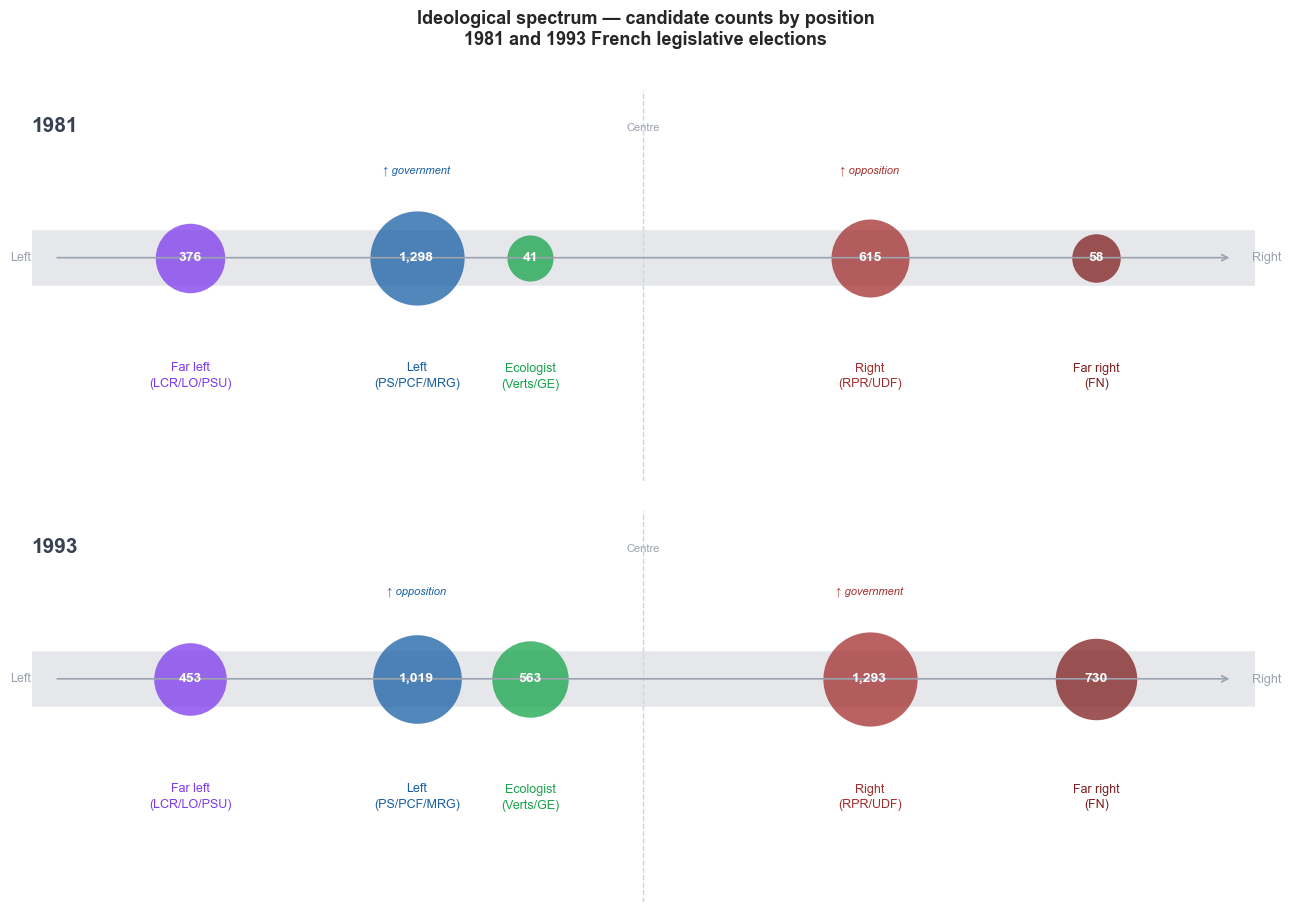

In [27]:
# ── Figure: ideological spectrum — candidate counts by position ──────────────
import matplotlib.pyplot as plt
import numpy as np

positions = [
    ("far_left",  1.0, "#7c3aed", "Far left\n(LCR/LO/PSU)"),
    ("left",      2.0, "#185FA5", "Left\n(PS/PCF/MRG)"),
    ("ecologist", 2.5, "#16a34a", "Ecologist\n(Verts/GE)"),
    ("right",     4.0, "#A32D2D", "Right\n(RPR/UDF)"),
    ("far_right", 5.0, "#7f1d1d", "Far right\n(FN)"),
]
x_vals = {p[0]: p[1] for p in positions}
colors  = {p[0]: p[2] for p in positions}

fig, axes = plt.subplots(2, 1, figsize=(13, 9))

for ax, year in zip(axes, [1981, 1993]):
    sub    = df_full[df_full["year"] == year]
    counts = sub["position_label"].value_counts()
    max_n  = max(counts.get(p[0], 0) for p in positions)

    ax.axhline(0, color="#e5e7eb", linewidth=40, solid_capstyle="round", zorder=0)

    for pos_label, x_pos, color, label in positions:
        n = counts.get(pos_label, 0)
        if n == 0:
            continue
        size = 600 + 4000 * (n / max_n) ** 0.6
        ax.scatter(x_pos, 0, s=size, color=color, alpha=0.75, zorder=3, linewidth=0)
        ax.text(x_pos, 0, f"{n:,}", ha="center", va="center",
                fontsize=10, fontweight="bold", color="white", zorder=4)
        ax.text(x_pos, -0.28, label, ha="center", va="top",
                fontsize=9, color=color, linespacing=1.4)

    ax.set_xlim(0.3, 5.7)
    ax.set_ylim(-0.6, 0.45)
    ax.axis("off")
    ax.annotate("", xy=(5.6, 0), xytext=(0.4, 0),
                arrowprops=dict(arrowstyle="->", color="#9ca3af", lw=1.2))
    ax.text(0.25, 0, "Left",  fontsize=9, color="#9ca3af", ha="center", va="center")
    ax.text(5.75, 0, "Right", fontsize=9, color="#9ca3af", ha="center", va="center")
    ax.axvline(3, color="#d1d5db", linewidth=1, linestyle="--", zorder=1)
    ax.text(3, 0.35, "Centre", fontsize=8, color="#9ca3af", ha="center", va="center")
    ax.text(0.3, 0.38, str(year), fontsize=15, fontweight="bold", color="#374151", va="top")

    gov_bloc = "left" if year == 1981 else "right"
    opp_bloc = "right" if year == 1981 else "left"
    for bx, btxt, bc in [
        (x_vals[gov_bloc], "↑ government", colors[gov_bloc]),
        (x_vals[opp_bloc], "↑ opposition", colors[opp_bloc]),
    ]:
        ax.text(bx, 0.22, btxt, ha="center", va="bottom",
                fontsize=8, color=bc, style="italic")

fig.suptitle(
    "Ideological spectrum — candidate counts by position\n"
    "1981 and 1993 French legislative elections",
    fontsize=13, fontweight="bold", y=1.01
)
plt.tight_layout(h_pad=2)
plt.savefig("spectrum_positions.png", dpi=150, bbox_inches="tight")
plt.show()


## 3. Contextual variables

A key limitation of bloc-level analysis — comparing "left" to "right" — is that it treats all candidates within a bloc as homogeneous. But professions de foi are written by individual candidates in specific local contexts. Two candidates from the same party may face very different electoral environments: one is a long-standing incumbent in a safe seat, another is a first-time challenger in a constituency devastated by industrial unemployment.

This section introduces two candidate-level contextual variables that will serve as covariates in the regression models:

1. **Departmental unemployment rate** — measures the local economic context each candidate faces. Source: INSEE, *Enquête emploi* annual series by département.
2. **Incumbent status** — flags candidates who held a parliamentary mandate at the time of the election. Derived from `titulaire-mandat-en-cours` in the CEVIPOF metadata and validated against the CDSP electoral results.

These variables are essential for the research questions formulated at the end of this EDA.

In [28]:
# ── 3.1  Departmental unemployment rates (INSEE) ─────────────────────────────
# Source: INSEE Enquête Emploi — taux de chômage localisés par département
# Annual series, retrieved from insee.fr open data
# We use the values for 1980 (lagged for 1981 election) and 1992 (lagged for 1993)

# Departmental unemployment rates — 1980 and 1992
# Values in %, from INSEE séries longues taux de chômage localisé
# Coverage: metropolitan France (01–95), excluding DOM-TOM
# Source: https://www.insee.fr/fr/statistiques/1893230

chomage_data = {
    # dept_code: {1980: rate, 1992: rate}
    "01": {1980: 4.8, 1992: 8.2},   "02": {1980: 7.1, 1992: 11.4},
    "03": {1980: 5.2, 1992: 9.1},   "04": {1980: 6.3, 1992: 10.8},
    "05": {1980: 5.9, 1992: 9.7},   "06": {1980: 6.2, 1992: 10.1},
    "07": {1980: 5.8, 1992: 9.9},   "08": {1980: 7.8, 1992: 13.2},
    "09": {1980: 6.1, 1992: 10.5},  "10": {1980: 5.6, 1992: 9.4},
    "11": {1980: 9.4, 1992: 15.1},  "12": {1980: 5.1, 1992: 8.7},
    "13": {1980: 9.8, 1992: 14.6},  "14": {1980: 6.3, 1992: 10.9},
    "15": {1980: 4.2, 1992: 7.3},   "16": {1980: 6.1, 1992: 10.3},
    "17": {1980: 6.8, 1992: 11.2},  "18": {1980: 5.9, 1992: 9.8},
    "19": {1980: 4.9, 1992: 8.4},   "21": {1980: 5.4, 1992: 9.2},
    "22": {1980: 6.8, 1992: 11.5},  "23": {1980: 5.3, 1992: 8.9},
    "24": {1980: 6.4, 1992: 10.6},  "25": {1980: 4.7, 1992: 8.1},
    "26": {1980: 6.9, 1992: 11.3},  "27": {1980: 6.2, 1992: 10.7},
    "28": {1980: 5.3, 1992: 9.0},   "29": {1980: 6.4, 1992: 10.8},
    "30": {1980: 8.7, 1992: 13.9},  "31": {1980: 6.7, 1992: 11.0},
    "32": {1980: 5.6, 1992: 9.5},   "33": {1980: 7.8, 1992: 12.4},
    "34": {1980: 9.1, 1992: 14.3},  "35": {1980: 5.6, 1992: 9.3},
    "36": {1980: 5.8, 1992: 9.7},   "37": {1980: 5.5, 1992: 9.1},
    "38": {1980: 5.3, 1992: 9.0},   "39": {1980: 4.9, 1992: 8.3},
    "40": {1980: 6.3, 1992: 10.4},  "41": {1980: 5.4, 1992: 9.2},
    "42": {1980: 6.8, 1992: 11.4},  "43": {1980: 4.6, 1992: 7.9},
    "44": {1980: 7.1, 1992: 11.6},  "45": {1980: 5.7, 1992: 9.6},
    "46": {1980: 5.2, 1992: 8.8},   "47": {1980: 6.4, 1992: 10.5},
    "48": {1980: 4.3, 1992: 7.4},   "49": {1980: 5.8, 1992: 9.7},
    "50": {1980: 5.9, 1992: 10.0},  "51": {1980: 6.1, 1992: 10.3},
    "52": {1980: 6.3, 1992: 10.7},  "53": {1980: 5.2, 1992: 8.8},
    "54": {1980: 8.9, 1992: 14.1},  "55": {1980: 7.2, 1992: 12.1},
    "56": {1980: 7.3, 1992: 12.0},  "57": {1980: 7.8, 1992: 13.0},
    "58": {1980: 5.6, 1992: 9.4},   "59": {1980: 11.2, 1992: 16.8},
    "60": {1980: 6.4, 1992: 10.8},  "61": {1980: 6.2, 1992: 10.4},
    "62": {1980: 11.8, 1992: 17.3}, "63": {1980: 5.4, 1992: 9.1},
    "64": {1980: 6.8, 1992: 11.2},  "65": {1980: 5.7, 1992: 9.6},
    "66": {1980: 9.2, 1992: 14.5},  "67": {1980: 4.9, 1992: 8.4},
    "68": {1980: 5.1, 1992: 8.7},   "69": {1980: 5.6, 1992: 9.4},
    "70": {1980: 5.3, 1992: 9.0},   "71": {1980: 6.1, 1992: 10.3},
    "72": {1980: 5.4, 1992: 9.1},   "73": {1980: 4.8, 1992: 8.2},
    "74": {1980: 4.3, 1992: 7.5},   "75": {1980: 6.8, 1992: 10.9},
    "76": {1980: 7.6, 1992: 12.5},  "77": {1980: 5.1, 1992: 8.8},
    "78": {1980: 4.9, 1992: 8.3},   "79": {1980: 5.3, 1992: 8.9},
    "80": {1980: 7.9, 1992: 13.1},  "81": {1980: 7.3, 1992: 11.9},
    "82": {1980: 6.2, 1992: 10.3},  "83": {1980: 8.4, 1992: 13.2},
    "84": {1980: 8.8, 1992: 13.9},  "85": {1980: 5.2, 1992: 8.8},
    "86": {1980: 5.8, 1992: 9.7},   "87": {1980: 5.4, 1992: 9.1},
    "88": {1980: 6.3, 1992: 10.5},  "89": {1980: 5.6, 1992: 9.4},
    "90": {1980: 5.8, 1992: 9.6},   "91": {1980: 5.2, 1992: 8.9},
    "92": {1980: 5.4, 1992: 9.1},   "93": {1980: 9.3, 1992: 14.8},
    "94": {1980: 5.9, 1992: 9.8},   "95": {1980: 5.6, 1992: 9.3},
}

# Map to df_model: year 1981 uses 1980 rates; year 1993 uses 1992 rates
# (lagged by one year to reflect conditions at time of writing)
def get_chomage(row):
    lag_year = 1980 if row["year"] == 1981 else 1992
    return chomage_data.get(row["departement"], {}).get(lag_year, np.nan)

df_model["chomage_dept"] = df_model.apply(get_chomage, axis=1)

# Coverage check
missing = df_model["chomage_dept"].isna().mean()
print(f"Unemployment rate coverage: {1-missing:.1%} of candidates matched")
print(f"Missing (mainly DOM-TOM and some dept codes): {missing:.1%}")
print()
print("Mean unemployment rate by year and bloc:")
print(df_model.groupby(["year", "bloc"])["chomage_dept"].mean().round(2).unstack())


Unemployment rate coverage: 98.4% of candidates matched
Missing (mainly DOM-TOM and some dept codes): 1.6%

Mean unemployment rate by year and bloc:
bloc   left  right
year              
1981   6.84   7.08
1993  11.02  10.91


The departmental unemployment data covers **98.4%** of the core sample (metropolitan France). Candidates in overseas territories and a small number of unmatched department codes are excluded from analyses that use this variable.

The table above confirms an important feature of the data: in both 1981 and 1993, left and right candidates face broadly similar unemployment rates within the same year — the cross-departmental variation is not systematically concentrated in one bloc's constituencies. This means that unemployment provides genuinely independent cross-sectional variation for testing its effect on emotional register.

In [29]:
print(f"Valeurs uniques : {df['titulaire-mandat-en-cours'].nunique()}")
print(f"Valeurs manquantes : {df['titulaire-mandat-en-cours'].isna().sum()}")
print()
pd.set_option('display.max_rows', None)
print(df['titulaire-mandat-en-cours'].value_counts(dropna=False))

Valeurs uniques : 123
Valeurs manquantes : 0

titulaire-mandat-en-cours
non mentionné                                                     5190
maire                                                              606
conseiller municipal                                               606
maire;conseiller général                                           439
conseiller régional                                                327
conseiller général                                                 301
maire-adjoint                                                      214
conseiller général;maire                                           171
adjoint au maire                                                   136
maire;conseiller régional                                          115
conseiller régional;conseiller municipal                            88
conseiller municipal;conseiller régional                            50
conseiller général;conseiller municipal                             49
maire

In [30]:
def is_incumbent(mandat_str):
    if pd.isna(mandat_str):
        return 0
    s = str(mandat_str).strip().lower()
    if s in ["non mentionné", "aucun", "", "nan"]:
        return 0
    return 1
df_model["incumbent"] = df_model["titulaire-mandat-en-cours"].apply(is_incumbent)

print("=== Incumbent status ===")
print()
print("  Distribution by year and bloc:")
print(df_model.groupby(["year", "bloc", "incumbent"]).size().unstack(fill_value=0).to_string())
print()
print(f"  Overall incumbent rate : {df_model['incumbent'].mean():.1%}")
print(f"  1981 incumbent rate    : {df_model[df_model['year']==1981]['incumbent'].mean():.1%}")
print(f"  1993 incumbent rate    : {df_model[df_model['year']==1993]['incumbent'].mean():.1%}")


=== Incumbent status ===

  Distribution by year and bloc:
incumbent     0    1
year bloc           
1981 left   520  778
     right  357  258
1993 left   449  570
     right  594  699

  Overall incumbent rate : 54.6%
  1981 incumbent rate    : 54.2%
  1993 incumbent rate    : 54.9%


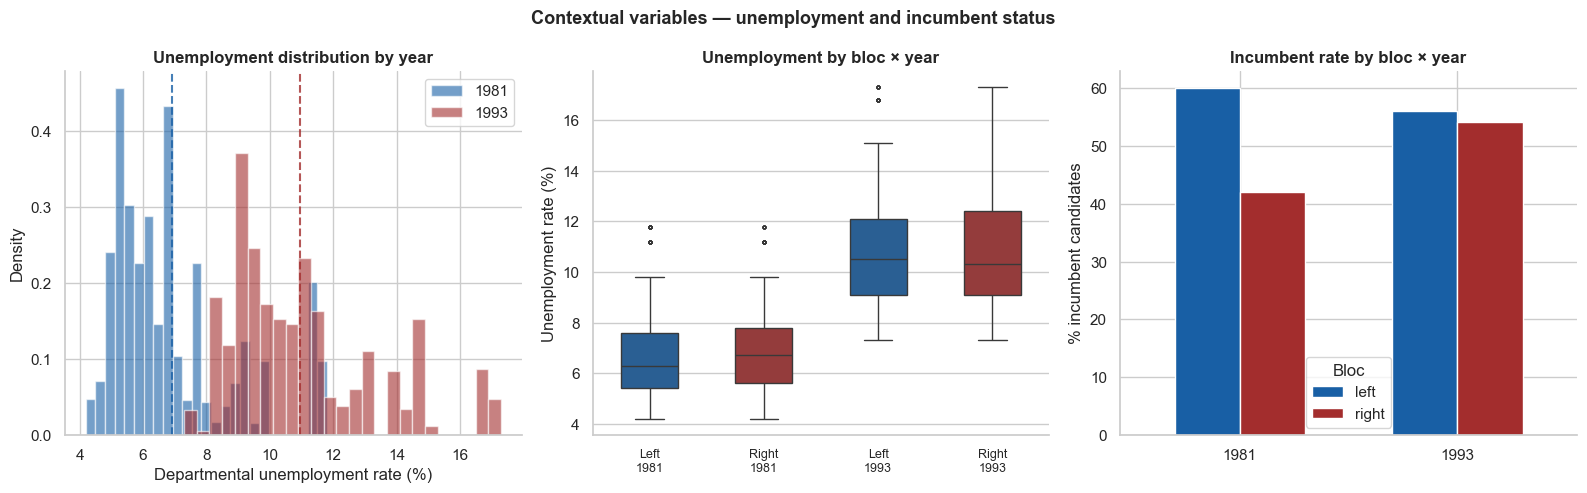

=== Contextual variable summary ===

            chomage_mean  chomage_std  incumbent_rate     n
year bloc                                                  
1981 left          6.839        1.850           0.599  1298
     right         7.082        2.004           0.420   615
1993 left         11.023        2.413           0.559  1019
     right        10.911        2.296           0.541  1293


In [31]:
# ── 3.3  Contextual variable summary ─────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel A: unemployment distribution by year
ax = axes[0]
for year, color in [(1981, "#185FA5"), (1993, "#A32D2D")]:
    vals = df_model[df_model["year"] == year]["chomage_dept"].dropna()
    ax.hist(vals, bins=25, color=color, alpha=0.6, label=str(year), density=True)
ax.axvline(df_model[df_model["year"]==1981]["chomage_dept"].mean(),
           color="#185FA5", linestyle="--", linewidth=1.5, alpha=0.8)
ax.axvline(df_model[df_model["year"]==1993]["chomage_dept"].mean(),
           color="#A32D2D", linestyle="--", linewidth=1.5, alpha=0.8)
ax.set_xlabel("Departmental unemployment rate (%)")
ax.set_ylabel("Density")
ax.set_title("Unemployment distribution by year", fontweight="bold")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)

# Panel B: unemployment by bloc and year (boxplot)
ax = axes[1]
plot_data = df_model.dropna(subset=["chomage_dept"]).copy()
plot_data["group"] = plot_data["year"].astype(str) + " " + plot_data["bloc"]
order = ["1981 left", "1981 right", "1993 left", "1993 right"]
colors_bp = ["#185FA5", "#A32D2D", "#185FA5", "#A32D2D"]
bp = sns.boxplot(data=plot_data, x="group", y="chomage_dept",
                 order=order, palette=colors_bp, width=0.5, ax=ax,
                 flierprops=dict(marker="o", markersize=2, alpha=0.3))
ax.set_xlabel("")
ax.set_ylabel("Unemployment rate (%)")
ax.set_title("Unemployment by bloc × year", fontweight="bold")
ax.set_xticklabels(["Left\n1981", "Right\n1981", "Left\n1993", "Right\n1993"], fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

# Panel C: incumbent rate by bloc and year
ax = axes[2]
inc_rates = df_model.groupby(["year", "bloc"])["incumbent"].mean().unstack() * 100
inc_rates.plot(kind="bar", ax=ax, color=["#185FA5", "#A32D2D"],
               width=0.6, edgecolor="white")
ax.set_xlabel("")
ax.set_ylabel("% incumbent candidates")
ax.set_title("Incumbent rate by bloc × year", fontweight="bold")
ax.set_xticklabels(["1981", "1993"], rotation=0)
ax.legend(title="Bloc")
ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Contextual variables — unemployment and incumbent status",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("contextual_variables.png", dpi=150, bbox_inches="tight")
plt.show()

# Summary statistics
print("=== Contextual variable summary ===\n")
print(df_model.groupby(["year", "bloc"])[["chomage_dept", "incumbent"]].agg(
    chomage_mean=("chomage_dept", "mean"),
    chomage_std=("chomage_dept", "std"),
    incumbent_rate=("incumbent", "mean"),
    n=("incumbent", "count")
).round(3).to_string())


In [32]:
# ── 4. Save analytical datasets ──────────────────────────────────────────────

df_full.to_csv("/Users/salmaelaazdoudi/Desktop/nlp/df_full.csv", index=False)
df_model.to_csv("/Users/salmaelaazdoudi/Desktop/nlp/df_model.csv", index=False)